##### <h1>class 05. Decision Trees</h1> <br/>


<b>Kuinka eroaa kNN luokittelusta?</b></br>
Molemmat mallit tekevät luokittelua. Päätöspuiden etu kNN malliin on, että päätöspuut ovat läpinäkyvämpia ja luokitteluennuste on selkeä. Dokumentointi on hyvin 'human-readable' ja viestintä on selkeämpää. Päätöspuiden koulutus on hitaampaa, mutta se tehdään vain kerran. Käyttö on simppelimpää ja selkeää. Huonopuoli päätöspuussa on se, että se on <i>joko-tai</i>, eli jos päätösraja on monimutkaisempi ja vastaus ei ole yksiselitteinen päätöspuut eivät osaa ottaa siihen kantaa. <br/>

---

<img src="./c5-img-01.jpg" width="400">




<br/>
<i>Root</i><br/>
<b>Outlook?</b> = 0.459<br/>
Yes: 9<br/>
No: 5<br/>

---
<h3>Gini-indeksi</h3>
-  <b>Paras mahdollinen g = 0.</b> <br/>
-  <b>"Millä todennäköisyydellä valitulle luokalle todennäköisyys osoittautuu vääräksi."</b> <br/>
-  
<br/>

$$ Py = \frac{9}{14} $$
$$ Pn = \frac{5}{14} $$

$$ g = 1 - P_y^2 - P_n^2$$

<br/>

---
<b>Sunny ( 5 ) = g1 = [ 1 - (2/5)^2 - (3/5)^2 ] = 0.48</b><br/>
Yes: 2 <br/>
No: 3 <br/><br/>
<b>Overcast ( 4 ) = g2 = 0</b><br/>
Yes: 4 <br/>
N: 0 <br/><br/>
<b>Rain ( 5 ) = g3 = [ 1 - (3/5)^2 - (2/5)^2 ] = 0.48</b><br/>
Yes: 3<br/>
No: 2<br/>

$$g = \frac{5}{14} \cdot 0.48 + \frac{4}{14} \cdot  0 + \frac{5}{14} \cdot  0.48 = 0.343$$
<br>

---

- Puuta ei kannata rakentaa liian yksityiskohtaisesti, tämä voi johtaa ylioppimiseen.
- Puulle kannattaa asettaa rajoitteita, ettei se kasva liikaa. Esim. maksimissaan depth 5
- sklearnissa ei ole kuin kaksihaaraa, nämä ovat binääripuita vastaus joko kyllä tai ei. Yläpuolella oleva esimerkki ei toimi sklearnissa semmoisenaan.
- sklearn edellyttää, että kaikki tyypit ovat numeerisia !!
  <br/>
- Tapa millä opitomoida puu on esimerkiksi
    - Annetaan puun kasvaa niin isoksi kun mahdollista
    - Aletaan katkomaan oksia alhaalta ja testataan vähentyikö ylioppiminen, onko puu optimaalisempi (prooning)

<br/>

- " 'min_samples_split' = 4" = [[ y:2 n:1]] <- (Solmua ei jaeta enempää ja tehdään päätös sen perusteella) | [[y:2 n:3]] <- ( vaatii lisäkysymyksiä )
- " 'min_samples_leaf' =  3" = [1] <- [[100 sampleä]] -> [99] => jakoa ei tehdä jos solmussa sämplejä alle 3 eli valitaan [sample 99]


---
<b>Kuvitellaan tilanne missä on dataa jolla ei ole selvää numeerista arvoa, esim kansalaisuudet.</b>
<br/><br/>
FIN = 0<br/>
SWE = 1<br/>
NOR = 3<br/>
DEN = 4<br/>
<br/>
<b>Ongelma:</b> Malli voi oppia, että suomalaisuus on kauempana norjalaisuudesta kun ruotsalaisuus, tai norjalaisuus on kaksi kertaa niin isompaa kuin ruotsi.
<br/><br/>
<b>Ratkaisu:</b><br/>
FIN = 1000<br/>
SWE = 0100<br/>
NOR = 0010<br/>
DEN = 0001<br/>
- one-hot encoding
- Vie enempi tilaa, mutta on fiksumpaa ja etäisyys pysyy samana.

---


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree  

df = pd.read_csv('../../datasets/iris.csv')
X = df.drop(['species'], axis = 1) # input features
y = df['species'].astype('category') # target features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20) # extract test set
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(112, 4) (38, 4) (112,) (38,)


In [5]:
model = DecisionTreeClassifier(max_depth=2, random_state=20)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=20)

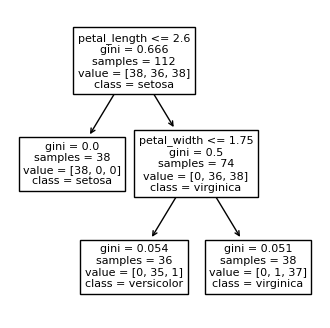

In [6]:
fig = plt.figure(figsize = (4, 4))
plot_tree(
    model,
    feature_names=list(X.keys()),
    class_names=['setosa', 'versicolor', 'virginica']
)
plt.show()

In [7]:
from sklearn.metrics import confusion_matrix

preds = model.predict(X_test)
confusion_matrix(y_test, preds)

array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  4,  8]], dtype=int64)

---

In [15]:
data = pd.read_csv('../../datasets/titanic_orig.csv').dropna()
data = data.drop(columns = ['PassengerId','Name','Ticket','Cabin','Embarked'])
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
1,1,1,female,38.0,1,0,71.2833
3,1,1,female,35.0,1,0,53.1000
6,0,1,male,54.0,0,0,51.8625
10,1,3,female,4.0,1,1,16.7000
11,1,1,female,58.0,0,0,26.5500


In [17]:
pd.get_dummies(data['Sex'], dtype='int64').head()

,female,male
1,1,0
3,1,0
6,0,1
10,1,0
11,1,0


In [19]:
data['Sex'] =pd.get_dummies(data['Sex'], dtype='int64')['female']
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
1,1,1,1,38.0,1,0,71.2833
3,1,1,1,35.0,1,0,53.1000
6,0,1,0,54.0,0,0,51.8625
10,1,3,1,4.0,1,1,16.7000
11,1,1,1,58.0,0,0,26.5500


In [21]:
X = data.drop(['Survived'], axis = 1) # input features
y = data['Survived'] # target features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(137, 6) (46, 6) (137,) (46,)


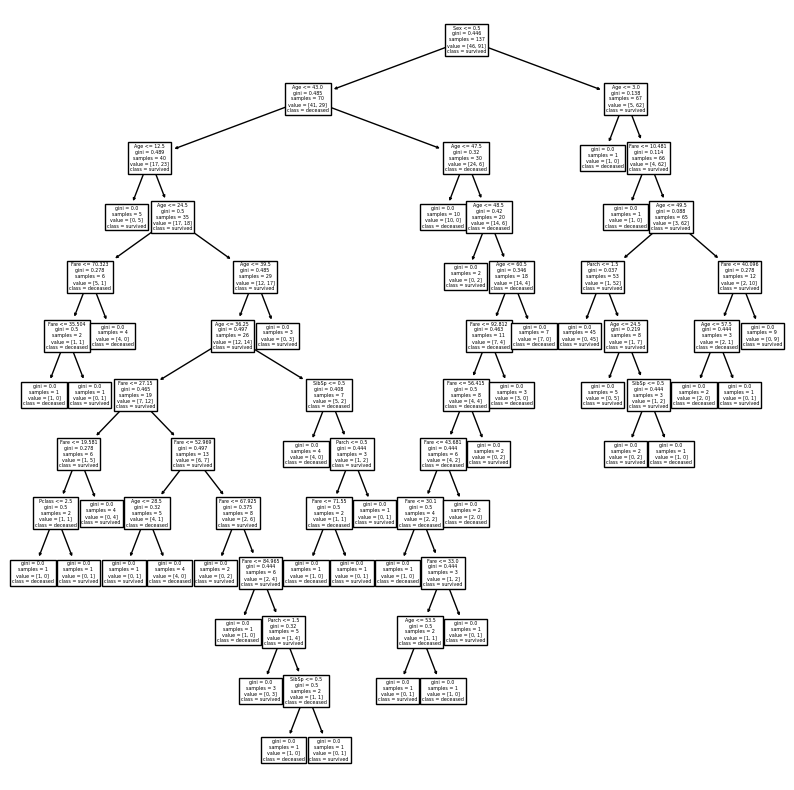

In [23]:
model = DecisionTreeClassifier(random_state=20).fit(X_train, y_train)
fig = plt.figure(figsize = (10, 10))
plot_tree(
    model,
    feature_names=list(X.keys()),
    class_names=['deceased', 'survived']
)
plt.show()

In [24]:
preds = model.predict(X_test)
confusion_matrix(y_test, preds)

array([[ 7,  7],
       [ 7, 25]], dtype=int64)

---
<h3>Prooning</h3>
- Tehdään prooning, eli karsitaan puun oksia.
- "Tämä on tällaista testaamista, mikä toimii parhaiten."

ccp_alpha, tällä tehdään prooninkia. Mitä isompi numero sitä enemmän oksia katkotaan ja 0 ei katkota yhtään.


Muutama sana testaamisesta: (Ei edellytetä viikkotehtävissä)
- Mallin data jaetaan testi dataan ja koulutusdataan
- Onglemaksi pelkästän tästä voi syntyä, että malli ylioppii koulutusdataan
- Tämän voisi korjata sllä, että jaetaankin malli kolmeen osaan (testi, koulutus ja validointi)
- Eli kun on testattu malli testidatalla ja sen toiminta on todettu hyväksi, niin kolmatta validointi dataa testataan vielä lopuski ja varmistetaan mallin oikeellisuus datalla, johon ei ole kajottu.

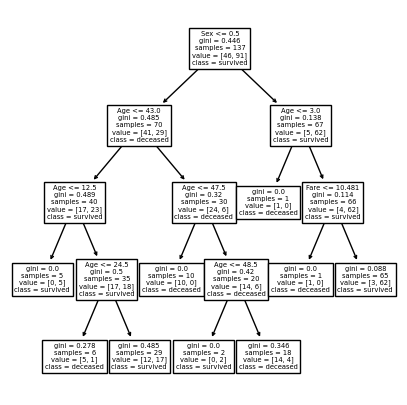

In [26]:
model_pruned = DecisionTreeClassifier(random_state=20, ccp_alpha=0.012).fit(X_train, y_train)
fig = plt.figure(figsize = (5, 5))
plot_tree(
    model_pruned,
    feature_names=list(X.keys()),
    class_names=['deceased', 'survived']
)
plt.show()

In [27]:
preds = model_pruned.predict(X_test)
confusion_matrix(y_test, preds)

array([[ 8,  6],
       [ 4, 28]], dtype=int64)